# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Análise de Dados com Linguagem Python</font>

## <font color='blue'>Projeto 9</font>
## <font color='blue'>Pré-Processamento de Dados de Texto Extraídos de Data Lake</font>

![title](imagens/Projeto9.png)

## Pré-Requisitos

Recomendamos que você tenha concluído pelo menos os 5 primeiros capítulos do curso gratuito de <a href="https://www.datascienceacademy.com.br/course?courseid=python-fundamentos">Python Fundamentos Para Análise de Dados</a>. Recomendamos ainda o capítulo sobre Machine Learning nesse mesmo curso.

### Definição do Problema e Fonte de Dados

Leia os manuais em pdf no Capítulo 10 do curso.

## Instalando e Carregando os Pacotes

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.8.20


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

In [3]:
#%pip install -q pymongo

In [4]:
# Imports
import json
import pymongo 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Data Science Academy" --iversions

Author: Data Science Academy

json      : 2.0.9
matplotlib: 3.7.5
numpy     : 1.21.0
pandas    : 1.3.3
platform  : 1.0.8
pymongo   : 4.10.1
seaborn   : 0.13.2



## Conectando no Data Lake

In [6]:
# Abre a conexão
client = pymongo.MongoClient("mongodb://localhost:27017/")
print(client)

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True)


In [7]:
# Visualiza a conexão
client

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True)

In [8]:
# Cria um repositório (banco de dados) chamado datalake
# datalake é o nome da variavel python que escolhemos, é gual o nome do banco
datalake = client["datalake"]

In [9]:
datalake

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'datalake')

In [10]:
# Se existir, deleta a coleção chamada posts
# Em bancos NoSql nao existe Tabelas e colunas igual bancos relacionais, e sim Colecao
datalake.posts.drop()


In [11]:
# Cria a coleção chamada posts
posts = datalake["posts"]
print(posts)

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'datalake'), 'posts')


## Carregando Dados no Data Lake

In [12]:
# Carrega o arquivo json em uma variável Python
with open('dados/dataset.json') as file:
    file_data = json.load(file)

In [13]:
file_data

[{'status': 'public',
  'creationDate': '2017-07-17T20:05:49Z',
  'allowComments': True,
  'title': 'ligula nec sem duis aliquam',
  'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
  'tags': 1,
  'Category': 'lifestyle',
  'filteredPicture': False},
 {'status': 'private',
  'creationDate': '2019-01-19T15:45:57Z',
  'allowComments': False,
  'title': 'mus vivamus vestibulum sagittis sapien cum',
  'description': 'nec nisi volutpat eleifend donec ut dolor morbi vel le

In [14]:
# Insere o conteúdo do arquivo json na coleção chamada posts. Cada item do arquivo será um documento.
posts.insert_many(file_data, ordered = False, bypass_document_validation = True)

InsertManyResult([ObjectId('69f76e7d5c272ae4066edfbd'), ObjectId('69f76e7d5c272ae4066edfbe'), ObjectId('69f76e7d5c272ae4066edfbf'), ObjectId('69f76e7d5c272ae4066edfc0'), ObjectId('69f76e7d5c272ae4066edfc1'), ObjectId('69f76e7d5c272ae4066edfc2'), ObjectId('69f76e7d5c272ae4066edfc3'), ObjectId('69f76e7d5c272ae4066edfc4'), ObjectId('69f76e7d5c272ae4066edfc5'), ObjectId('69f76e7d5c272ae4066edfc6'), ObjectId('69f76e7d5c272ae4066edfc7'), ObjectId('69f76e7d5c272ae4066edfc8'), ObjectId('69f76e7d5c272ae4066edfc9'), ObjectId('69f76e7d5c272ae4066edfca'), ObjectId('69f76e7d5c272ae4066edfcb'), ObjectId('69f76e7d5c272ae4066edfcc'), ObjectId('69f76e7d5c272ae4066edfcd'), ObjectId('69f76e7d5c272ae4066edfce'), ObjectId('69f76e7d5c272ae4066edfcf'), ObjectId('69f76e7d5c272ae4066edfd0'), ObjectId('69f76e7d5c272ae4066edfd1'), ObjectId('69f76e7d5c272ae4066edfd2'), ObjectId('69f76e7d5c272ae4066edfd3'), ObjectId('69f76e7d5c272ae4066edfd4'), ObjectId('69f76e7d5c272ae4066edfd5'), ObjectId('69f76e7d5c272ae4066edf

In [15]:
# Retorna 1 item
posts.find_one()

{'_id': ObjectId('69f76e7d5c272ae4066edfbd'),
 'status': 'public',
 'creationDate': '2017-07-17T20:05:49Z',
 'allowComments': True,
 'title': 'ligula nec sem duis aliquam',
 'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
 'tags': 1,
 'Category': 'lifestyle',
 'filteredPicture': False}

In [16]:
# Extrai o número de documentos (posts)
n = posts.estimated_document_count()

In [17]:
n

2000

## Pré-Processamento e Análise

> Agregação para calcular o número de posts em cada categoria.

In [18]:
# Agregação para calcular o número de posts em cada categoria
# 🔹 Objetivo geral do bloco:
# Este comando realiza uma agregação em uma coleção chamada "posts".
# A ideia é calcular quantos posts existem em cada categoria
# e depois ordenar os resultados para facilitar a análise.

# 🔹 Linha por linha:

# posts_cat = posts.aggregate([...])
# -> Aqui estamos chamando o método "aggregate" sobre a coleção "posts".
#    O aggregate permite aplicar operações de transformação e agrupamento
#    em documentos do MongoDB (ou Data Lake compatível).
# -> O resultado será armazenado na variável "posts_cat".

# [{"$group": {"_id": "$Category", "count": {"$sum": 1}}}, ...]
# -> Este é o primeiro estágio da agregação: "$group".
# -> "_id": "$Category" significa que os documentos serão agrupados
#    pelo campo "Category". Ou seja, cada categoria será uma chave única.
# -> "count": {"$sum": 1} cria um contador. Para cada documento dentro
#    de uma categoria, soma +1. Assim, obtemos o total de posts por categoria.

# {"$sort": {"_id.Category": 1, "count": -1}}
# -> Este é o segundo estágio da agregação: "$sort".
# -> "_id.Category": 1 indica ordenação crescente pelo nome da categoria.
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Na prática, isso organiza os resultados primeiro por categoria
#    e dentro disso mostra as categorias mais populares primeiro.

# 🔹 Interpretação prática:
# Imagine que temos posts com categorias como "Esportes", "Tecnologia" e "Música".
# O "$group" vai contar quantos posts existem em cada uma dessas categorias.
# O "$sort" vai organizar os resultados, mostrando por exemplo:
#   Esportes -> 120 posts
#   Tecnologia -> 95 posts
#   Música -> 40 posts
# Assim, conseguimos rapidamente identificar quais categorias têm mais conteúdo.


posts_cat = posts.aggregate([{"$group": {"_id": "$Category", "count": {"$sum": 1}}},
                             {"$sort": {"_id.Category": 1, "count": -1}}])

In [19]:
print(posts_cat)

In [20]:
# Converte o resultado da agregação em um dataframe
pc_df = pd.DataFrame(list(posts_cat))

In [21]:
pc_df.head()

,_id,count
0,arts,311
1,fashion,300
2,lifestyle,294
3,movies,289
4,educational,274


In [22]:
# Listas os ids (categorias)
list(pc_df['_id'])

['arts', 'fashion', 'lifestyle', 'movies', 'educational', 'politics', 'sports']

<Axes: ylabel='count'>

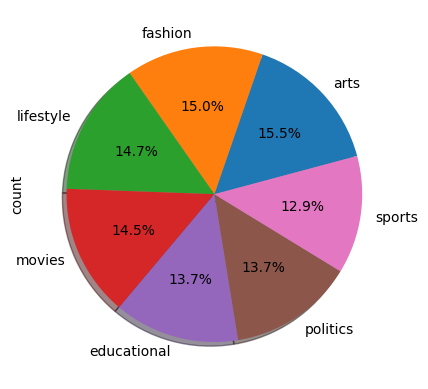

In [23]:
# Plot
pc_df.plot.pie(y = 'count',
               labels = pc_df['_id'],
               autopct = '%1.1f%%',
               startangle = 15, 
               shadow = True,
               legend = False)

> Número de posts públicos e privados da categoria **politics**.

In [24]:
# Número de posts públicos e privados da categoria politics
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts públicos e privados existem
# dentro da categoria "politics". Assim conseguimos entender
# a distribuição dos status (por exemplo: "public" vs "private")
# apenas para essa categoria específica.

# 🔹 Linha por linha:

# pol_sta = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "pol_sta".

# {"$match": {"Category": "politics"}}
# -> Primeiro estágio da agregação: "$match".
# -> Filtra os documentos, mantendo apenas aqueles
#    cuja categoria seja "politics".
# -> Isso garante que os cálculos seguintes sejam feitos
#    apenas sobre posts dessa categoria.

# {"$group": {"_id": "$status", "count": {"$sum": 1}}}
# -> Segundo estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "status".
#    O campo "_id" recebe o valor de "$status",
#    ou seja, cada grupo será "public" ou "private".
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts públicos e privados
#    na categoria "politics".

# 🔹 Interpretação prática:
# Imagine que temos 300 posts na categoria "politics".
# Destes, 180 são públicos e 120 são privados.
# O resultado da agregação será algo como:
#   { "_id": "public", "count": 180 }
#   { "_id": "private", "count": 120 }
# Isso permite analisar a proporção de visibilidade
# dos posts políticos no Data Lake.



pol_sta = posts.aggregate([{"$match": {"Category": "politics"}},
                           {"$group": {"_id": "$status", "count": {"$sum": 1}}}])

In [25]:
ps_df = pd.DataFrame(list(pol_sta))

In [26]:
ps_df

,_id,count
0,private,148
1,public,126


<Axes: title={'center': 'Número de Posts Públicos e Privados'}, xlabel='_id'>

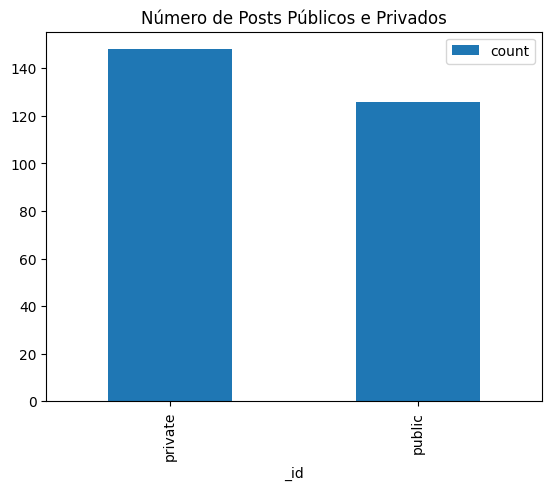

In [27]:
# Plot
ps_df.plot.bar(x = '_id',
               y = 'count',
               title = "Número de Posts Públicos e Privados")

> Qual ano teve o maior número de posts?

In [28]:
# Retorna 1 item
posts.find_one()

{'_id': ObjectId('69f76e7d5c272ae4066edfbd'),
 'status': 'public',
 'creationDate': '2017-07-17T20:05:49Z',
 'allowComments': True,
 'title': 'ligula nec sem duis aliquam',
 'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
 'tags': 1,
 'Category': 'lifestyle',
 'filteredPicture': False}

In [29]:
# Update many (cria duas noovas variáveis para cada documento)
# 🔹 Objetivo geral do bloco:
# Este comando adiciona duas novas variáveis (campos) em todos os documentos
# da coleção "posts" dentro do Data Lake.
# As variáveis criadas são "hour" e "year", ambas inicializadas com valor 0.

# 🔹 Linha por linha:

# datalake.posts.update_many({}, {'$set': {"hour": 0}});
# -> Chamamos o método "update_many" sobre a coleção "posts".
# -> O primeiro parâmetro "{}" significa que não há filtro:
#    todos os documentos da coleção serão atualizados.
# -> O segundo parâmetro usa o operador "$set":
#    ele cria ou atualiza o campo "hour" com o valor 0.
# -> Resultado: cada documento passa a ter um campo "hour" = 0.

# datalake.posts.update_many({}, {'$set': {"year": 0}});
# -> Novamente usamos "update_many" sem filtro, afetando todos os documentos.
# -> O operador "$set" cria ou atualiza o campo "year" com o valor 0.
# -> Resultado: cada documento passa a ter um campo "year" = 0.

# 🔹 Interpretação prática:
# Imagine que cada documento representa um post extraído do Data Lake.
# Inicialmente, eles não tinham informações explícitas de hora ou ano.
# Com esse comando, garantimos que todos os documentos tenham os campos:
#   "hour": 0
#   "year": 0
# Isso é útil para padronizar a estrutura dos dados,
# permitindo que futuramente possamos preencher esses campos
# com valores reais (por exemplo, a hora e o ano de publicação do post).


datalake.posts.update_many({}, {'$set': {"hour": 0}});
datalake.posts.update_many({}, {'$set': {"year": 0}});

In [30]:
# Retorna 1 item
posts.find_one()

{'_id': ObjectId('69f76e7d5c272ae4066edfbd'),
 'status': 'public',
 'creationDate': '2017-07-17T20:05:49Z',
 'allowComments': True,
 'title': 'ligula nec sem duis aliquam',
 'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
 'tags': 1,
 'Category': 'lifestyle',
 'filteredPicture': False,
 'hour': 0,
 'year': 0}

In [31]:
# Update one (atualiza as duas variáveis com os valores correspondentes extraídos da coluna de data)
# 🔹 Objetivo geral do bloco:
# Este código percorre todos os documentos da coleção "posts"
# e atualiza cada um deles, extraindo a hora e o ano
# a partir do campo "creationDate".
# Assim, os campos "hour" e "year" passam a ter valores reais
# em vez de apenas o valor inicial 0.

# 🔹 Linha por linha:

# for data in posts.find({}):
# -> Percorre todos os documentos da coleção "posts".
# -> O método "find({})" retorna todos os documentos (sem filtro).
# -> Cada documento é armazenado na variável "data" durante a iteração.

# posts.update_one({"_id": data['_id']}, {...})
# -> Atualiza um único documento por vez.
# -> O filtro {"_id": data['_id']} garante que apenas o documento atual
#    (aquele que está sendo iterado) seja atualizado.
# -> Dessa forma, não corremos o risco de alterar outros documentos.

# {'$set': {'hour' : data['creationDate'].split('T')[1].split(':')[0],
#           'year' : data['creationDate'].split('T')[0].split('-')[0] }}
# -> O operador "$set" cria ou atualiza os campos "hour" e "year".
# -> Para "hour":
#    - data['creationDate'] é uma string no formato ISO (ex: "2024-07-15T13:45:00").
#    - split('T')[1] pega a parte após o "T" → "13:45:00".
#    - split(':')[0] pega apenas a hora → "13".
# -> Para "year":
#    - split('T')[0] pega a parte antes do "T" → "2024-07-15".
#    - split('-')[0] pega apenas o ano → "2024".
# -> Resultado: o documento passa a ter os campos:
#    "hour": "13"
#    "year": "2024"

# 🔹 Interpretação prática:
# Imagine que temos um post com:
#   "creationDate": "2024-07-15T13:45:00"
# Após rodar esse código, o documento será atualizado para:
#   "hour": "13"
#   "year": "2024"
# Isso facilita análises temporais, como:
#   - Quantos posts foram feitos em cada hora do dia?
#   - Quantos posts foram feitos em cada ano?


for data in posts.find({}):
    posts.update_one({"_id": data['_id']},
                     {'$set': {'hour' : data['creationDate'].split('T')[1].split(':')[0],
                               'year' : data['creationDate'].split('T')[0].split('-')[0] }})

In [32]:
# Retorna 1 item
posts.find_one()

{'_id': ObjectId('69f76e7d5c272ae4066edfbd'),
 'status': 'public',
 'creationDate': '2017-07-17T20:05:49Z',
 'allowComments': True,
 'title': 'ligula nec sem duis aliquam',
 'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
 'tags': 1,
 'Category': 'lifestyle',
 'filteredPicture': False,
 'hour': '20',
 'year': '2017'}

In [33]:
# Agregação por ano

# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts existem em cada ano
# e organiza os resultados em ordem crescente de ano e de quantidade.
# Assim conseguimos visualizar a evolução temporal dos posts no Data Lake.

# 🔹 Linha por linha:

# posts_yr = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "posts_yr".

# {"$group": {"_id": "$year", "count": {"$sum": 1}}}
# -> Primeiro estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "year".
#    O campo "_id" recebe o valor de "$year", ou seja, cada grupo será um ano.
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts por ano.

# {"$sort": {"_id.year": 1, "count": 1}}
# -> Segundo estágio da agregação: "$sort".
# -> "_id.year": 1 indica ordenação crescente pelo ano.
# -> "count": 1 indica ordenação crescente pelo número de posts.
# -> Resultado: os anos aparecem em ordem cronológica,
#    e dentro disso os anos com menos posts aparecem primeiro.

# 🔹 Interpretação prática:
# Imagine que temos posts nos anos 2022, 2023 e 2024.
# O "$group" vai contar quantos posts existem em cada ano.
# O "$sort" vai organizar os resultados, mostrando por exemplo:
#   2022 -> 50 posts
#   2023 -> 120 posts
#   2024 -> 200 posts
# Isso permite analisar a evolução do volume de posts ao longo do tempo,
# identificando tendências de crescimento ou queda.


posts_yr = posts.aggregate([{"$group": {"_id": "$year", "count": {"$sum": 1}}},
                            {"$sort": {"_id.year": 1, "count": 1}}])

In [34]:
py_df = pd.DataFrame(list(posts_yr))
py_df

,_id,count
0,2015,76
1,2016,299
2,2019,303
3,2017,309
4,2021,330
5,2020,334
6,2018,349


<Axes: title={'center': 'Número de Posts Por Ano'}, xlabel='_id'>

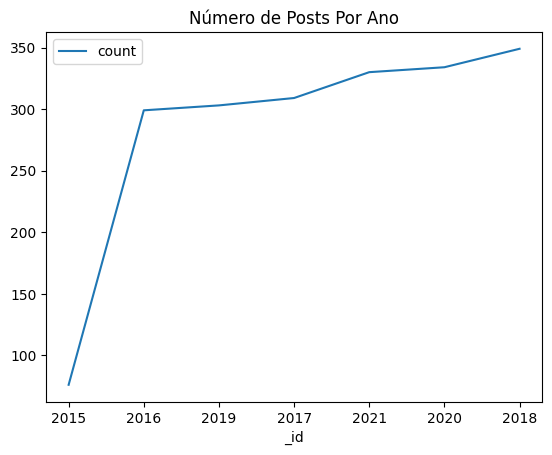

In [35]:
# Plot
py_df.plot.line(x = '_id',
                y = 'count',
                title = "Número de Posts Por Ano")

> Qual o horário com maior número de posts?

In [36]:
# Agregação e ordenação
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts foram feitos em cada hora do dia
# e organiza os resultados em ordem crescente de hora,
# destacando primeiro as horas com maior número de posts.

# 🔹 Linha por linha:

# posts_hr = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "posts_hr".

# {"$group": {"_id": "$hour", "count": {"$sum": 1}}}
# -> Primeiro estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "hour".
#    O campo "_id" recebe o valor de "$hour", ou seja, cada grupo será uma hora (0 a 23).
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts por hora.

# {"$sort": {"_id.hour": 1, "count": -1}}
# -> Segundo estágio da agregação: "$sort".
# -> "_id.hour": 1 indica ordenação crescente pela hora (0 → 23).
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado: os horários aparecem em ordem cronológica,
#    mas dentro disso as horas com mais posts aparecem primeiro.

# 🔹 Interpretação prática:
# Imagine que temos posts feitos às 10h, 13h e 20h.
# O "$group" vai contar quantos posts existem em cada hora.
# O "$sort" vai organizar os resultados, mostrando por exemplo:
#   10h -> 50 posts
#   13h -> 120 posts
#   20h -> 80 posts
# Isso permite analisar os horários de maior atividade dos usuários,
# identificando picos de publicação ao longo do dia.


posts_hr = posts.aggregate([{"$group": {"_id": "$hour", "count": {"$sum": 1}}},
                            {"$sort": {"_id.hour": 1, "count": -1}}])

In [37]:
# 🔹 Objetivo geral do bloco:
# Este código imprime os três primeiros resultados da agregação "posts_hr",
# que contém a contagem de posts por hora do dia.
# Assim conseguimos visualizar rapidamente os horários mais ativos.

# 🔹 Linha por linha:

# for i in range(3):
# -> Cria um loop que será executado 3 vezes (i = 0, 1, 2).
# -> Isso significa que vamos imprimir apenas os três primeiros registros
#    retornados pela agregação "posts_hr".

# print(posts_hr.next())
# -> O método "next()" retorna o próximo documento do cursor "posts_hr".
# -> Cada documento contém:
#    "_id": valor da hora (ex: "13")
#    "count": número de posts naquela hora
# -> O "print" exibe esse documento no console/notebook.

# 🔹 Interpretação prática:
# Suponha que a agregação "posts_hr" tenha produzido os seguintes resultados:
#   { "_id": "10", "count": 50 }
#   { "_id": "13", "count": 120 }
#   { "_id": "20", "count": 80 }
#   { "_id": "22", "count": 40 }
# O loop vai imprimir apenas os três primeiros:
#   {'_id': '10', 'count': 50}
#   {'_id': '13', 'count': 120}
#   {'_id': '20', 'count': 80}
# Isso permite uma inspeção rápida dos dados sem precisar visualizar toda a lista.

for i in range(3):
    print(posts_hr.next())

{'_id': '00', 'count': 103}
{'_id': '08', 'count': 101}
{'_id': '02', 'count': 99}


> Número de posts em hora cheia (terminada por 00) por categoria.

In [38]:
# Filtro, agregação e ordenação
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts foram feitos exatamente à meia-noite (hora "00")
# e organiza os resultados por categoria, mostrando quais categorias
# são mais frequentes nesse horário.

# 🔹 Linha por linha:

# cat_00 = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "cat_00".

# {"$match": {"hour": "00"}}
# -> Primeiro estágio da agregação: "$match".
# -> Filtra os documentos, mantendo apenas aqueles
#    cuja hora seja "00" (meia-noite).
# -> Isso garante que os cálculos seguintes sejam feitos
#    apenas sobre posts publicados nesse horário.

# {"$group": {"_id": "$Category", "count": {"$sum": 1}}}
# -> Segundo estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "Category".
#    O campo "_id" recebe o valor de "$Category", ou seja,
#    cada grupo será uma categoria (ex: "politics", "sports").
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts por categoria à meia-noite.

# {"$sort": {"_id.Category": 1, "count": -1}}
# -> Terceiro estágio da agregação: "$sort".
# -> "_id.Category": 1 indica ordenação crescente pelo nome da categoria.
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado: as categorias aparecem em ordem alfabética,
#    mas dentro disso as mais populares (com mais posts) aparecem primeiro.

# 🔹 Interpretação prática:
# Imagine que às 00h foram publicados 200 posts.
# Destes, 80 são da categoria "politics", 70 de "sports" e 50 de "music".
# O resultado da agregação será algo como:
#   { "_id": "politics", "count": 80 }
#   { "_id": "sports", "count": 70 }
#   { "_id": "music", "count": 50 }
# Isso permite analisar quais categorias são mais ativas
# em horários específicos, como a madrugada.


cat_00 = posts.aggregate([{"$match": {"hour": "00"}},
                          {"$group": {"_id": "$Category", "count": {"$sum": 1}}},
                          {"$sort": {"_id.Category": 1, "count": -1}}])

In [39]:
c0_df = pd.DataFrame(list(cat_00))

<Axes: title={'center': 'Número de Posts em Hora Cheia'}, xlabel='_id'>

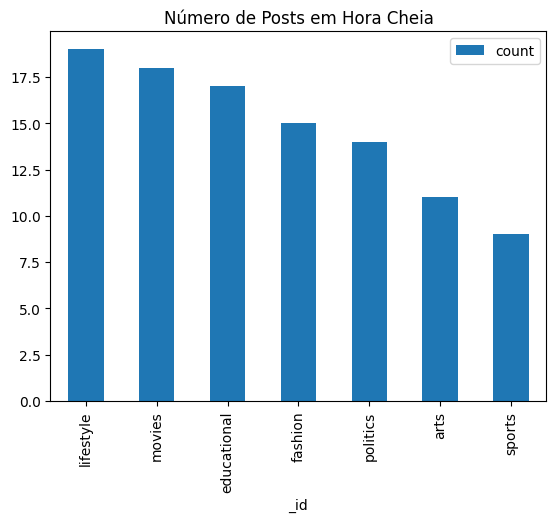

In [40]:
c0_df.plot.bar(x = '_id', y = 'count', title = "Número de Posts em Hora Cheia")

> Número de posts que permitem comentários.

In [41]:
# Count
# 🔹 Objetivo geral do bloco:
# Este comando conta quantos documentos (posts) permitem comentários,
# ou seja, quantos têm o campo "allowComments" definido como True.

# 🔹 Linha por linha:

# com = posts.count_documents({'allowComments':True})
# -> Chamamos o método "count_documents" sobre a coleção "posts".
# -> O parâmetro {'allowComments': True} é um filtro:
#    seleciona apenas os documentos em que o campo "allowComments"
#    está definido como True.
# -> O método retorna o número total de documentos que atendem a esse critério.
# -> O resultado é armazenado na variável "com".

# 🔹 Interpretação prática:
# Imagine que temos 1.000 posts no total.
# Destes, 650 permitem comentários (allowComments = True).
# O comando vai retornar o valor 650 e armazenar em "com".
# Assim, conseguimos saber rapidamente a proporção de posts
# que permitem interação dos usuários.


com = posts.count_documents({'allowComments':True})

In [42]:
print("Número de Posts Que Permitem Comentários:", com)

Número de Posts Que Permitem Comentários: 964


In [43]:
print("Número de Posts Que Não Permitem Comentários:", n-com)

Número de Posts Que Não Permitem Comentários: 1036


Text(0, 0.5, 'Numero de Posts')

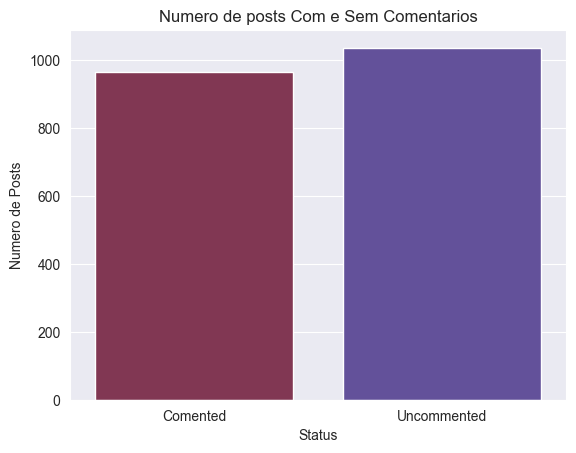

In [44]:
# plot

sns.set_style('darkgrid')  
# -> Define o estilo visual do gráfico.
x = ['Comented', 'Uncommented']  
# -> Rótulos para o eixo X.
y = [com, n-com]  
# -> Valores correspondentes (posts com e sem comentários).
sns.barplot(x=x, y=y, palette='twilight_r')  
# -> Agora passamos os parâmetros nomeados:
#    - x=x → rótulos das categorias
#    - y=y → valores numéricos
#    - palette='twilight_r' → paleta de cores
plt.title("Numero de posts Com e Sem Comentarios")  
# -> Define o título do gráfico.
plt.xlabel("Status")  
# -> Rótulo do eixo X.
plt.ylabel("Numero de Posts")  
# -> Rótulo do eixo Y.

> Comprimento (número de palavras) do título dos posts.

In [45]:
# Retorna 1 item
posts.find_one()

{'_id': ObjectId('69f76e7d5c272ae4066edfbd'),
 'status': 'public',
 'creationDate': '2017-07-17T20:05:49Z',
 'allowComments': True,
 'title': 'ligula nec sem duis aliquam',
 'description': 'in felis eu sapien cursus vestibulum proin eu mi nulla ac enim in tempor turpis nec euismod scelerisque quam turpis adipiscing lorem vitae mattis nibh ligula nec sem duis aliquam convallis nunc proin at turpis a pede posuere nonummy integer non velit donec diam neque vestibulum eget vulputate ut ultrices vel augue vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae donec pharetra magna vestibulum aliquet ultrices erat tortor sollicitudin mi sit amet lobortis sapien sapien non mi integer ac neque duis bibendum morbi non',
 'tags': 1,
 'Category': 'lifestyle',
 'filteredPicture': False,
 'hour': '20',
 'year': '2017'}

In [46]:
# Cria uma nova coluna
# 🔹 Objetivo geral do bloco:
# Este comando adiciona um novo campo chamado "length_of_heading"
# em todos os documentos da coleção "posts" dentro do Data Lake,
# inicializando-o com o valor 0.
# Esse campo provavelmente será usado depois para armazenar
# o tamanho (número de caracteres) do título/heading de cada post.

# 🔹 Linha por linha:

# datalake.posts.update_many({}, {'$set': {"length_of_heading": 0}});
# -> Chamamos o método "update_many" sobre a coleção "posts".
# -> O primeiro parâmetro "{}" significa que não há filtro:
#    todos os documentos da coleção serão atualizados.
# -> O segundo parâmetro usa o operador "$set":
#    ele cria ou atualiza o campo "length_of_heading" com o valor 0.
# -> Resultado: cada documento passa a ter o campo "length_of_heading" = 0.

# 🔹 Interpretação prática:
# Imagine que cada documento representa um post com um título (heading).
# Inicialmente, os documentos não tinham um campo que armazenasse
# o tamanho desse título.
# Com esse comando, garantimos que todos os documentos tenham o campo:
#   "length_of_heading": 0
# Isso padroniza a estrutura dos dados e prepara o terreno
# para uma etapa futura, onde calcularemos o tamanho real do título
# e atualizaremos esse campo com o valor correto.


datalake.posts.update_many({}, {'$set': {"length_of_heading": 0}});

In [47]:
# Loop para preencher a nova coluna
# 🔹 Objetivo geral do bloco:
# Este código percorre todos os documentos da coleção "posts"
# e atualiza cada um deles com o tamanho real do título (heading).
# O campo "length_of_heading" passa a armazenar o número de palavras
# presentes no título de cada post.

# 🔹 Linha por linha:

# for data in posts.find({}):
# -> Percorre todos os documentos da coleção "posts".
# -> O método "find({})" retorna todos os documentos (sem filtro).
# -> Cada documento é armazenado na variável "data" durante a iteração.

# posts.update_one({"_id": data['_id']}, {...})
# -> Atualiza um único documento por vez.
# -> O filtro {"_id": data['_id']} garante que apenas o documento atual
#    (aquele que está sendo iterado) seja atualizado.

# {'$set': {'length_of_heading' : len(data['title'].split(' '))}}
# -> O operador "$set" cria ou atualiza o campo "length_of_heading".
# -> data['title'] acessa o título do post.
# -> .split(' ') divide o título em uma lista de palavras,
#    usando o espaço como separador.
# -> len(...) conta quantos elementos (palavras) existem nessa lista.
# -> Resultado: o campo "length_of_heading" recebe o número de palavras
#    do título do post.

# 🔹 Interpretação prática:
# Imagine que temos um post com:
#   "title": "Análise de Dados em Python"
# O comando .split(' ') gera a lista:
#   ["Análise", "de", "Dados", "em", "Python"]
# O len(...) retorna 5.
# O documento será atualizado para:
#   "length_of_heading": 5
# Isso permite analisar estatisticamente os títulos,
# como identificar se posts com títulos mais longos
# têm maior engajamento ou não.


for data in posts.find({}):
    posts.update_one({"_id": data['_id']},
                     {'$set': {'length_of_heading' : len(data['title'].split(' '))}})

In [48]:
# Agrupamento e ordenação
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos títulos (headings) possuem determinado tamanho
# em número de palavras, e organiza os resultados em ordem crescente de tamanho.
# Assim conseguimos visualizar a distribuição do comprimento dos títulos.

# 🔹 Linha por linha:

# len_titles = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "len_titles".

# {"$group": {"_id": "$length_of_heading", "count": {"$sum": 1}}}
# -> Primeiro estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "length_of_heading".
#    O campo "_id" recebe o valor de "$length_of_heading",
#    ou seja, cada grupo será um tamanho específico de título (ex: 3 palavras, 5 palavras).
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de títulos com determinado comprimento.

# {"$sort": {"_id.length_of_heading": 1, "count": -1}}
# -> Segundo estágio da agregação: "$sort".
# -> "_id.length_of_heading": 1 indica ordenação crescente pelo tamanho do título.
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado: os comprimentos de título aparecem em ordem crescente,
#    e dentro disso os mais frequentes aparecem primeiro.

# 🔹 Interpretação prática:
# Imagine que temos títulos com diferentes tamanhos:
#   - 3 palavras → 120 posts
#   - 5 palavras → 200 posts
#   - 7 palavras → 80 posts
# O resultado da agregação será algo como:
#   { "_id": 3, "count": 120 }
#   { "_id": 5, "count": 200 }
#   { "_id": 7, "count": 80 }
# Isso permite analisar se os títulos tendem a ser curtos ou longos
# e se há algum padrão de popularidade relacionado ao tamanho.


len_titles = posts.aggregate([{"$group": {"_id": "$length_of_heading", "count": {"$sum": 1}}},
                              {"$sort": {"_id.length_of_heading": 1, "count": -1}}])

In [49]:
len_titles 

In [50]:
title_df = pd.DataFrame(list(len_titles))
title_df.head(10)

,_id,count
0,3,355
1,4,345
2,1,343
3,5,337
4,6,336
5,2,284


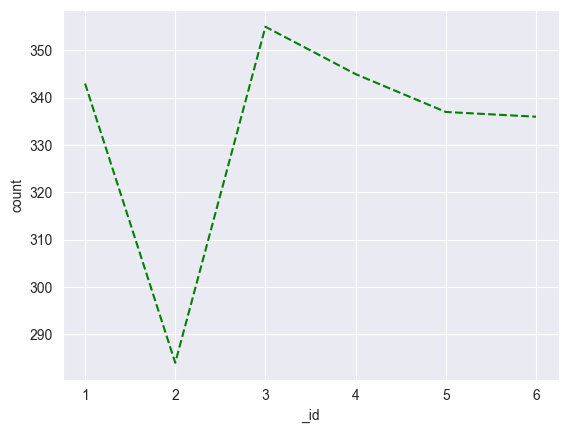

In [51]:
# Plot
ax = sns.lineplot(x = '_id', y = 'count', data = title_df, color = 'green')
ax.lines[0].set_linestyle("--")
plt.show()

> Número de tags por categoria de posts.

In [52]:
# Agregação
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts estão associados a cada tag
# e organiza os resultados em ordem alfabética de tag,
# destacando primeiro as tags mais frequentes.

# 🔹 Linha por linha:

# tags = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "tags".

# {"$group": {"_id": "$tags", "count": {"$sum": 1}}}
# -> Primeiro estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "tags".
#    O campo "_id" recebe o valor de "$tags", ou seja,
#    cada grupo será uma tag específica (ex: "python", "AI", "sports").
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts associados a cada tag.

# {"$sort": {"_id.tags": 1, "count": -1}}
# -> Segundo estágio da agregação: "$sort".
# -> "_id.tags": 1 indica ordenação crescente pelo nome da tag.
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado: as tags aparecem em ordem alfabética,
#    mas dentro disso as mais populares aparecem primeiro.

# 🔹 Interpretação prática:
# Imagine que temos posts com as seguintes tags:
#   - "python" → 150 posts
#   - "AI" → 200 posts
#   - "sports" → 80 posts
# O resultado da agregação será algo como:
#   { "_id": "AI", "count": 200 }
#   { "_id": "python", "count": 150 }
#   { "_id": "sports", "count": 80 }
# Isso permite identificar quais temas/tags são mais recorrentes
# nos posts armazenados no Data Lake.


tags = posts.aggregate([{"$group": {"_id": "$tags", "count": {"$sum": 1}}},
                        {"$sort": {"_id.tags": 1, "count": -1}}])

In [53]:
# 🔹 Objetivo geral do bloco:
# Este comando busca todos os documentos da coleção "posts"
# que possuem o campo "tags" maior que 0 (ou seja, posts com pelo menos uma tag).
# Em seguida, retorna apenas o campo "Category" desses documentos.
# Isso permite analisar quais categorias estão associadas a posts com tags.

# 🔹 Linha por linha:

# cat_tags = posts.find({'tags': {'$gt':0}}, {'Category':1})
# -> Executa uma consulta na coleção "posts".
# -> O primeiro parâmetro {'tags': {'$gt':0}} é o filtro:
#    seleciona apenas os documentos em que o campo "tags" é maior que 0.
#    Isso significa que estamos interessados apenas em posts que possuem tags.
# -> O segundo parâmetro {'Category':1} é a projeção:
#    indica que queremos retornar apenas o campo "Category" dos documentos.
#    O "_id" geralmente também é retornado por padrão, a menos que seja explicitamente excluído.

# cat_tags
# -> Armazena o cursor da consulta na variável "cat_tags".
# -> Esse cursor pode ser iterado ou convertido em lista para visualizar os resultados.
# -> Cada documento retornado terá a forma:
#    { "_id": <id_do_post>, "Category": <nome_da_categoria> }
# Interpretação prática:  
#Se temos posts como:
#Post 1: tags = ["python", "AI"], Category = "technology"
#Post 2: tags = ["sports"], Category = "sports"
#Post 3: tags = [], Category = "politics"
#A consulta vai retornar apenas os posts 1 e 2 (porque têm tags), mostrando:
#{ "_id": ..., "Category": "technology" }
#{ "_id": ..., "Category": "sports" }



cat_tags = posts.find({'tags': {'$gt':0}}, {'Category':1})
cat_tags

In [54]:
# Categorias com posts com maior número de tags, sendo o número de tags maior do que zero
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts possuem tags (tags > 0)
# e organiza os resultados por categoria, mostrando quais categorias
# concentram mais posts com tags associadas.

# 🔹 Linha por linha:

# cat_tags = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "cat_tags".

# {"$match": {"tags": {"$gt":0}}}
# -> Primeiro estágio da agregação: "$match".
# -> Filtra os documentos, mantendo apenas aqueles
#    cujo campo "tags" seja maior que 0.
# -> Isso garante que os cálculos seguintes sejam feitos
#    apenas sobre posts que possuem tags.

# {"$group": {"_id": "$Category", "count": {"$sum": 1}}}
# -> Segundo estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "Category".
#    O campo "_id" recebe o valor de "$Category", ou seja,
#    cada grupo será uma categoria (ex: "politics", "sports").
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts com tags em cada categoria.

# {"$sort": {"_id.tags": 1, "count": -1}}
# -> Terceiro estágio da agregação: "$sort".
# ⚠️ Aqui há um detalhe: "_id.tags" não faz sentido,
#    pois o agrupamento foi feito por "Category".
#    O correto seria ordenar por "_id" (categoria) ou por "count".
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado esperado: categorias aparecem em ordem alfabética
#    ou por popularidade, dependendo do ajuste.

# 🔹 Interpretação prática:
# Imagine que temos posts com tags nas seguintes categorias:
#   - "politics" → 120 posts com tags
#   - "sports" → 80 posts com tags
#   - "technology" → 200 posts com tags
# O resultado da agregação será algo como:
#   { "_id": "technology", "count": 200 }
#   { "_id": "politics", "count": 120 }
#   { "_id": "sports", "count": 80 }
# Isso permite identificar quais categorias concentram mais posts
# enriquecidos com tags.


cat_tags = posts.aggregate([{"$match": {"tags": {"$gt":0}}},
                            {"$group": {"_id": "$Category", "count": {"$sum": 1}}},
                            {"$sort": {"_id.tags": 1, "count": -1}}])

In [55]:
# 🔹 Objetivo geral do bloco:
# Transformar o cursor retornado pela agregação MongoDB em um DataFrame Pandas,
# permitindo manipulação mais simples dos dados (estatísticas, gráficos, etc.).

# 🔹 Linha por linha:

# ct_df = pd.DataFrame(list(cat_tags))
# -> "cat_tags" é um cursor retornado pela agregação.
# -> A função list(cat_tags) transforma esse cursor em uma lista de dicionários.
#    Cada dicionário corresponde a um documento do resultado da agregação.
#    Exemplo: [{ "_id": "sports", "count": 80 }, { "_id": "technology", "count": 200 }]
# -> pd.DataFrame(...) converte essa lista em um DataFrame Pandas.
# -> O DataFrame terá colunas "_id" (categoria) e "count" (quantidade de posts).

# ct_df
# -> Exibe o DataFrame resultante.

ct_df = pd.DataFrame(list(cat_tags))
ct_df

,_id,count
0,arts,276
1,fashion,276
2,movies,264
3,lifestyle,262
4,politics,258
5,educational,255
6,sports,235


<Axes: xlabel='_id', ylabel='count'>

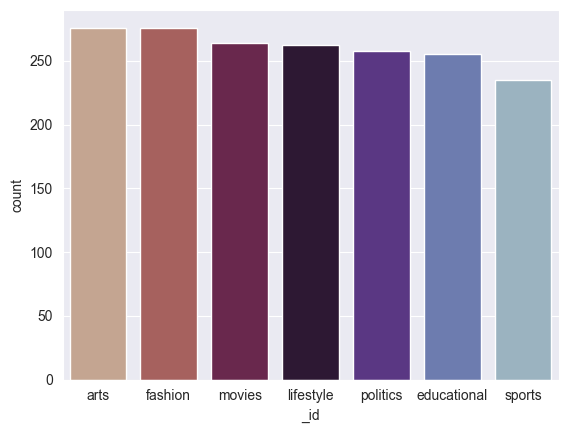

In [56]:
sns.barplot(x = '_id', y = 'count', data = ct_df, palette = 'twilight_r')

> Qual categoria usa mais filtros de fotos/imagens?

In [57]:
# Filtro, agregação e ordenação
# 🔹 Objetivo geral do bloco:
# Este comando calcula quantos posts possuem imagens filtradas
# (campo "filteredPicture" = True) e organiza os resultados por categoria.
# Assim conseguimos identificar quais categorias concentram mais posts
# com imagens que passaram por algum tipo de filtro.

# 🔹 Linha por linha:

# cat_fs = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "cat_fs".

# {"$match": {"filteredPicture": True}}
# -> Primeiro estágio da agregação: "$match".
# -> Filtra os documentos, mantendo apenas aqueles
#    cujo campo "filteredPicture" seja True.
# -> Isso garante que os cálculos seguintes sejam feitos
#    apenas sobre posts com imagens filtradas.

# {"$group":{"_id": "$Category", "count": {"$sum": 1}}}
# -> Segundo estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "Category".
#    O campo "_id" recebe o valor de "$Category", ou seja,
#    cada grupo será uma categoria (ex: "politics", "sports").
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts com imagens filtradas em cada categoria.

# {"$sort": {"_id.tags": 1, "count": -1}}
# -> Terceiro estágio da agregação: "$sort".
# ⚠️ Aqui há um detalhe: "_id.tags" não faz sentido,
#    pois o agrupamento foi feito por "Category".
#    O correto seria ordenar por "_id" (categoria) ou por "count".
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado esperado: categorias aparecem em ordem alfabética
#    ou por popularidade, dependendo do ajuste.

# 🔹 Interpretação prática:
# Imagine que temos posts com imagens filtradas nas seguintes categorias:
#   - "technology" → 150 posts
#   - "sports" → 80 posts
#   - "politics" → 50 posts
# O resultado da agregação será algo como:
#   { "_id": "technology", "count": 150 }
#   { "_id": "sports", "count": 80 }
#   { "_id": "politics", "count": 50 }
# Isso permite identificar quais categorias concentram mais posts
# com imagens que passaram por filtragem.


cat_fs = posts.aggregate([{"$match": {"filteredPicture": True}},
                          {"$group":{"_id": "$Category", "count": {"$sum": 1}}},
                          {"$sort": {"_id.tags": 1, "count": -1}}])

In [58]:
# 🔹 Objetivo geral do bloco:
# Mostrar uma amostra dos resultados da agregação "cat_fs",
# que contém a contagem de posts com imagens filtradas por categoria.

# 🔹 Linha por linha:

# for i in range(7):
# -> Cria um loop que será executado 7 vezes (i = 0, 1, 2, ..., 6).
# -> Isso significa que vamos imprimir apenas os sete primeiros registros
#    retornados pela agregação "cat_fs".

# print(cat_fs.next())
# -> O método "next()" retorna o próximo documento do cursor "cat_fs".
# -> Cada documento contém:
#    "_id": nome da categoria (ex: "sports", "technology")
#    "count": número de posts com imagens filtradas naquela categoria
# -> O "print" exibe esse documento no console/notebook.


for i in range(7):
    print(cat_fs.next())

{'_id': 'fashion', 'count': 159}
{'_id': 'movies', 'count': 154}
{'_id': 'arts', 'count': 146}
{'_id': 'lifestyle', 'count': 136}
{'_id': 'educational', 'count': 135}
{'_id': 'politics', 'count': 131}
{'_id': 'sports', 'count': 117}


> Nível Ninja: Qual categoria tem posts (descrição) mais longos (com maior número de palavras), acima de 60 caracteres?

In [63]:
# Cria a variável
# 🔹 Objetivo geral do bloco:
# Criar ou atualizar o campo "length_of_des" em todos os documentos da coleção "posts",
# atribuindo inicialmente o valor 0. Esse campo provavelmente será usado
# para armazenar o tamanho (número de palavras ou caracteres) da descrição de cada post.

# 🔹 Linha por linha:

# datalake.posts.update_many({}, {'$set': {"length_of_des": 0}});
# -> Chamamos o método "update_many" sobre a coleção "posts".
# -> O primeiro parâmetro "{}" significa que não há filtro:
#    todos os documentos da coleção serão atualizados.
# -> O segundo parâmetro usa o operador "$set":
#    ele cria ou atualiza o campo "length_of_des" com o valor 0.
# -> Resultado: cada documento passa a ter o campo "length_of_des": 0.


datalake.posts.update_many({}, {'$set': {"length_of_des": 0}});

In [64]:
# Loop para preencher a variável
# 🔹 Objetivo geral do bloco:
# Calcular o número de palavras na descrição de cada post
# e armazenar esse valor no campo "length_of_des".

# 🔹 Linha por linha:

# for data in posts.find({}):
# -> Percorre todos os documentos da coleção "posts".
# -> O método find({}) retorna todos os documentos (sem filtro).
# -> Cada documento é armazenado na variável "data" durante a iteração.

# posts.update_one({"_id": data['_id']}, {...})
# -> Atualiza um único documento por vez.
# -> O filtro {"_id": data['_id']} garante que apenas o documento atual
#    (aquele que está sendo iterado) seja atualizado.

# {'$set': {'length_of_des': len(data['description'].split(' '))}}
# -> O operador "$set" cria ou atualiza o campo "length_of_des".
# -> data['description'] acessa o texto da descrição do post.
# -> .split(' ') divide a descrição em uma lista de palavras,
#    usando o espaço como separador.
# -> len(...) conta quantos elementos (palavras) existem nessa lista.
# -> Resultado: o campo "length_of_des" recebe o número de palavras
#    da descrição do post.



for data in posts.find({}):
    posts.update_one({"_id": data['_id']}, {'$set': {'length_of_des': len(data['description'].split(' '))}})

In [61]:
# Filtro, agregação e ordenação
# 🔹 Objetivo geral do bloco:
# Identificar posts cuja descrição tem pelo menos 60 palavras
# e agrupar esses posts por categoria, mostrando quais categorias
# concentram mais descrições longas.

# 🔹 Linha por linha:

# cat_des = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "cat_des".

# {"$match": {"length_of_des": {"$gte":60}}}
# -> Primeiro estágio da agregação: "$match".
# -> Filtra os documentos, mantendo apenas aqueles
#    cujo campo "length_of_des" seja maior ou igual a 60.
# -> Isso garante que os cálculos seguintes sejam feitos
#    apenas sobre posts com descrições longas.

# {"$group":{"_id": "$Category", "count": {"$sum": 1}}}
# -> Segundo estágio da agregação: "$group".
# -> Agrupa os documentos pelo campo "Category".
#    O campo "_id" recebe o valor de "$Category", ou seja,
#    cada grupo será uma categoria (ex: "politics", "sports").
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts com descrições longas em cada categoria.

# {"$sort": {"_id.tags": 1, "count": -1}}
# -> Terceiro estágio da agregação: "$sort".
# ⚠️ Aqui há um detalhe: "_id.tags" não faz sentido,
#    pois o agrupamento foi feito por "Category".
#    O correto seria ordenar por "_id" (categoria) ou por "count".
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado esperado: categorias aparecem em ordem alfabética
#    ou por popularidade, dependendo do ajuste.


cat_des = posts.aggregate([{"$match": {"length_of_des": {"$gte":60}}},
                           {"$group":{"_id": "$Category", "count": {"$sum": 1}}},
                           {"$sort": {"_id.tags": 1, "count": -1}}])

In [62]:
# 🔹 Objetivo geral do bloco:
# Exibir uma amostra dos resultados da agregação "cat_des",
# que contém a contagem de posts com descrições longas (≥ 60 palavras)
# agrupados por categoria.

# 🔹 Linha por linha:

# for i in range(7):
# -> Cria um loop que será executado 7 vezes (i = 0, 1, 2, ..., 6).
# -> Isso significa que vamos imprimir apenas os sete primeiros registros
#    retornados pela agregação "cat_des".

# print(cat_des.next())
# -> O método "next()" retorna o próximo documento do cursor "cat_des".
# -> Cada documento contém:
#    "_id": nome da categoria (ex: "sports", "technology")
#    "count": número de posts com descrições longas naquela categoria
# -> O "print" exibe esse documento no console/notebook.


for i in range(7):
    print(cat_des.next())

{'_id': 'arts', 'count': 178}
{'_id': 'fashion', 'count': 161}
{'_id': 'movies', 'count': 159}
{'_id': 'educational', 'count': 156}
{'_id': 'lifestyle', 'count': 156}
{'_id': 'politics', 'count': 146}
{'_id': 'sports', 'count': 130}


> Nível Ninja das Galáxias: O número de posts (descrição) varia de acordo com a hora do dia? Aumenta ou diminui?

In [65]:
# Agregação e ordenação por hora e categoria
# 🔹 Objetivo geral do bloco:
# Agrupar os posts por hora de publicação e categoria,
# contando quantos posts existem em cada combinação.
# Isso permite analisar padrões de atividade ao longo do dia
# e comparar entre categorias.

# 🔹 Linha por linha:

# posts_hr = posts.aggregate([...])
# -> Executa uma agregação sobre a coleção "posts".
# -> O resultado será armazenado na variável "posts_hr".

# {"$group": {"_id": ["$hour", "$Category"], "count": {"$sum": 1}}}
# -> Primeiro estágio da agregação: "$group".
# -> Agrupa os documentos por dois campos: "hour" e "Category".
#    O campo "_id" será uma lista contendo [hora, categoria].
#    Exemplo: [14, "sports"] → posts publicados às 14h na categoria "sports".
# -> "count": {"$sum": 1} cria um contador,
#    somando +1 para cada documento dentro de cada grupo.
# -> Resultado: número total de posts por hora e categoria.

# {"$sort": {"_id.hour": 1, "count": -1}}
# -> Segundo estágio da agregação: "$sort".
# ⚠️ Aqui há um detalhe: como o "_id" é uma lista [hour, Category],
#    não existe "_id.hour" diretamente.
#    O correto seria usar algo como {"$sort": {"_id.0": 1, "count": -1}}
#    onde "_id.0" representa o primeiro elemento da lista (hour).
# -> "count": -1 indica ordenação decrescente pelo número de posts.
# -> Resultado esperado: posts ordenados primeiro pela hora do dia,
#    e dentro de cada hora, pelas categorias mais populares.


posts_hr = posts.aggregate([{"$group": {"_id": ["$hour", "$Category"], "count": {"$sum": 1}}},
                            {"$sort": {"_id.hour": 1, "count": -1}}])

In [66]:
# 🔹 Objetivo geral do bloco:
# Converter o resultado da agregação "posts_hr" em um DataFrame Pandas
# para facilitar a análise estatística e visualização dos posts por hora e categoria.

# 🔹 Linha por linha:

# postshr_df = pd.DataFrame(list(posts_hr))
# -> "posts_hr" é um cursor retornado pela agregação do MongoDB.
# -> A função list(posts_hr) transforma esse cursor em uma lista de dicionários.
#    Cada dicionário corresponde a um documento do resultado da agregação.
#    Exemplo: [{ "_id": [10, "sports"], "count": 50 }, { "_id": [14, "politics"], "count": 40 }]
# -> pd.DataFrame(...) converte essa lista em um DataFrame Pandas.
# -> O DataFrame terá colunas "_id" (lista com [hora, categoria]) e "count" (quantidade de posts).

# postshr_df
# -> Exibe o DataFrame resultante.
# -> Inicialmente, a coluna "_id" será uma lista com dois elementos: [hora, categoria].
# -> Para facilitar a análise, podemos separar essa coluna em duas colunas distintas:
#    "hour" e "category".


postshr_df = pd.DataFrame(posts_hr)
postshr_df

,_id,count
0,"[11, arts]",23
1,"[08, politics]",21
2,"[16, lifestyle]",20
3,"[11, educational]",20
4,"[02, lifestyle]",19
...,...,...
163,"[22, politics]",5
164,"[06, sports]",5
165,"[13, sports]",5
166,"[11, lifestyle]",4


In [67]:
# Split
# 🔹 Objetivo geral do bloco:
# Separar a coluna "_id" do DataFrame "postshr_df" em duas colunas distintas:
# "hour" (hora de publicação) e "category" (categoria do post).
# Isso facilita a análise e a visualização dos dados.

# 🔹 Linha por linha:

# split_df = pd.DataFrame(postshr_df['_id'].to_list(), columns=['hour', 'category'])
# -> postshr_df['_id'] contém listas com dois elementos: [hora, categoria].
#    Exemplo: [10, "sports"], [14, "politics"].
# -> .to_list() transforma essa coluna em uma lista de listas.
# -> pd.DataFrame(..., columns=['hour', 'category']) cria um novo DataFrame
#    com duas colunas: "hour" e "category".
# -> Resultado: cada linha terá a hora e a categoria separadas em colunas próprias.

# split_df
# -> Exibe o DataFrame resultante.
# -> Agora temos um DataFrame organizado com colunas "hour" e "category",
#    pronto para análises estatísticas ou criação de gráficos.


split_df = pd.DataFrame(postshr_df ['_id'].to_list(), columns = ['hour', 'category'])
split_df

,hour,category
0,11,arts
1,08,politics
2,16,lifestyle
3,11,educational
4,02,lifestyle
...,...,...
163,22,politics
164,06,sports
165,13,sports
166,11,lifestyle


In [68]:
# Concatenação
# 🔹 Objetivo geral do bloco:
# Combinar o DataFrame "split_df" (que contém as colunas "hour" e "category")
# com a coluna "count" do DataFrame original "postshr_df".
# O resultado final será um DataFrame completo com três colunas:
# "hour", "category" e "count".

# 🔹 Linha por linha:

# df = pd.concat([split_df, postshr_df['count']], axis=1)
# -> pd.concat([...], axis=1) concatena DataFrames ou séries lado a lado (colunas).
# -> split_df contém as colunas "hour" e "category".
# -> postshr_df['count'] é uma série com o número de posts em cada combinação hora-categoria.
# -> axis=1 indica concatenação por colunas (horizontal).
# -> Resultado: um novo DataFrame com as colunas "hour", "category" e "count".

# df
# -> Exibe o DataFrame resultante.
# -> Agora temos todas as informações organizadas em colunas separadas,
#    prontas para análise estatística ou visualização gráfica.


df = pd.concat([split_df, postshr_df['count']], axis = 1)
df

,hour,category,count
0,11,arts,23
1,08,politics,21
2,16,lifestyle,20
3,11,educational,20
4,02,lifestyle,19
...,...,...,...
163,22,politics,5
164,06,sports,5
165,13,sports,5
166,11,lifestyle,4


In [69]:
df.head(10)

,hour,category,count
0,11,arts,23
1,08,politics,21
2,16,lifestyle,20
3,11,educational,20
4,02,lifestyle,19
5,05,arts,19
6,10,fashion,19
7,00,lifestyle,19
8,08,movies,18
9,22,lifestyle,18


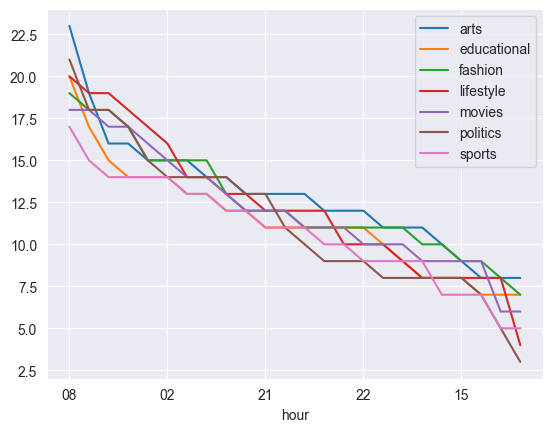

In [70]:
# Plot
fig, ax = plt.subplots()
for key, grp in df.groupby(['category']):
    ax = grp.plot(ax = ax, kind = 'line', x = 'hour', y = 'count', label = key)

plt.legend(loc = 'best')
plt.show()

In [71]:
# Plot
# 🔹 Objetivo do gráfico:
# Mostrar a quantidade de posts por hora em cada categoria.
# Cada linha representa uma categoria (arts, educational, fashion, lifestyle,
# movies, politics, sports) e o eixo X mostra as horas do dia.
# O eixo Y mostra o número de posts.

# 🔹 Interpretação:
# - Todas as categorias apresentam uma tendência de queda ao longo das horas,
#   ou seja, o volume de posts diminui conforme o dia avança.
# - Algumas categorias começam com valores mais altos (como movies e educational)
#   e caem mais rapidamente.
# - Outras, como sports e politics, mantêm uma presença mais estável,
#   mas também seguem a curva descendente.
# - Isso sugere que há picos de atividade em horários iniciais
#   e depois uma redução gradual.

# 🔹 Utilidade:
# Esse tipo de visualização ajuda a identificar os horários mais fortes
# para cada categoria. Por exemplo:
# - Publicar conteúdo de fashion ou movies nos horários iniciais
#   pode gerar maior engajamento.
# - Sports e politics têm relevância em horários variados,
#   mas ainda seguem a tendência de queda.


# Fim